# Travel Reimbursement Approval Agent

### AI Developer Candidate Assignment

**Candidate:** Nandigam Neelkkamaal  
**Implementation:** Python, Jupyter Notebook, deterministic policy tools, and AI-assisted reasoning  
**Data:** Mock travel reimbursement policy and five synthetic claims supplied with the assignment

---

## Solution Overview

This notebook implements a lightweight, policy-grounded Travel Reimbursement Approval Agent. The agent evaluates employee travel claims against category eligibility, receipt requirements, per-diem limits, submission timelines, airfare-class rules, and approval thresholds.

For each claim, the agent returns one of the following recommendations:

- `APPROVE`
- `PARTIAL_APPROVE`
- `REJECT`
- `MANUAL_REVIEW`

The solution uses deterministic Python tools for financial calculations and policy enforcement. A GenAI layer can assist with tool planning and explanation generation. The deterministic workflow remains available as a reliable fallback when an LLM API is unavailable.

> **Important:** This prototype uses only the mock policy and synthetic claims provided in the assignment. It does not contain real employee or company data.

## README

### Purpose

The Travel Reimbursement Approval Agent evaluates claims using the supplied travel policy and returns transparent, auditable, and structured recommendations.

### Key Capabilities

1. Accepts reimbursement claims represented as structured Python dictionaries equivalent to JSON input.
2. Retrieves relevant policy rules by stable `POL-*` identifiers.
3. Calls specialized tools for:
   - Category eligibility
   - Receipt completeness
   - Airfare-class compliance
   - Per-diem and category limits
   - Submission timeliness
   - Approval thresholds
   - Output validation
4. Preserves an audit trail of the tools and policies used.
5. Routes missing, conflicting, exceptional, or high-value cases to `MANUAL_REVIEW`.
6. Produces a JSON array containing exactly the required output fields.
7. Generates a dashboard from the actual evaluated claim results.

### Runtime Requirements

- Python 3.10 or later
- Jupyter Notebook
- pandas
- matplotlib
- ipywidgets

### Setup

Create and activate a virtual environment, then install the required packages:

```text
python -m venv .venv
.venv\Scripts\activate
python -m pip install notebook pandas matplotlib ipywidgets
jupyter notebook

## Solution Architecture

The prototype uses a hybrid agentic design:

```text
Structured Claim Input
        |
        v
Agent Orchestrator
        |
        +--> Policy Lookup Tool
        +--> Category Eligibility Tool
        +--> Receipt Completeness Tool
        +--> Airfare Compliance Tool
        +--> Per-Diem Limit Tool
        +--> Timeliness Tool
        +--> Approval Threshold Tool
        |
        v
Deterministic Decision Engine
        |
        +--> Optional GenAI Explanation Layer
        |
        v
Structured Output Validator
        |
        v
JSON Recommendation + Audit Trail + Dashboard

## Implementation Objectives

This notebook demonstrates:

- **Claim intake:** Claims are loaded from structured JSON-compatible data.
- **Context grounding:** Relevant policy rules are looked up before recommendations are finalized.
- **Tool usage:** Specialized functions evaluate eligibility, receipts, limits, timeliness, and approval authority.
- **Agentic orchestration:** An orchestration layer selects and combines tool results for each claim.
- **Ambiguity handling:** Missing documents, policy exceptions, high-value claims, late submissions, and conflicts trigger Manual Review.
- **Structured output:** Every claim produces the exact fields required by the assignment.
- **Validation:** Candidate outputs are validated before being accepted.
- **Observability:** Tool calls, policy references, and intermediate findings are available as an audit trail.
- **Dashboard:** Actual claim outcomes are summarized through data-driven metrics and charts.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import ipywidgets as widgets 

In [2]:
# Standard-library imports
import json
import os
import sys
import platform
from copy import deepcopy
from datetime import datetime
from decimal import Decimal, ROUND_HALF_UP
from typing import Any, Dict, List, Optional, Tuple

# Third-party imports
import pandas as pd
import matplotlib.pyplot as plt
import ipywidgets as widgets

from IPython.display import display, HTML, Markdown, clear_output


# -----------------------------
# Notebook-level configuration
# -----------------------------

NOTEBOOK_TITLE = "Travel Reimbursement Approval Agent"
CURRENCY = "USD"

ALLOWED_DECISIONS = {
    "APPROVE",
    "PARTIAL_APPROVE",
    "REJECT",
    "MANUAL_REVIEW",
}

REQUIRED_OUTPUT_FIELDS = [
    "claim_id",
    "decision",
    "approved_amount",
    "deducted_amount",
    "missing_docs",
    "policy_refs",
    "confidence",
    "explanation",
    "tools_used",
]

MONEY_QUANTIZER = Decimal("0.01")


def to_money(value: Any) -> Decimal:
    """
    Convert a numeric value to a two-decimal-place Decimal.

    Decimal is used internally to reduce floating-point rounding risk
    during reimbursement calculations.
    """
    return Decimal(str(value)).quantize(
        MONEY_QUANTIZER,
        rounding=ROUND_HALF_UP,
    )


def money_to_float(value: Decimal) -> float:
    """Convert an internal Decimal amount to a JSON-serializable float."""
    return float(value.quantize(MONEY_QUANTIZER, rounding=ROUND_HALF_UP))


print(f"{NOTEBOOK_TITLE} setup completed successfully.")
print(f"Python version: {platform.python_version()}")
print(f"Python executable: {sys.executable}")
print(f"Pandas version: {pd.__version__}")
print(f"Allowed decisions: {sorted(ALLOWED_DECISIONS)}")

Travel Reimbursement Approval Agent setup completed successfully.
Python version: 3.12.4
Python executable: C:\Users\ASUS\travel-reimbursement-agent\.venv\Scripts\python.exe
Pandas version: 3.0.3
Allowed decisions: ['APPROVE', 'MANUAL_REVIEW', 'PARTIAL_APPROVE', 'REJECT']


## Policy Knowledge Base

The supplied travel reimbursement policy is represented below as structured, machine-readable context. Each policy retains its stable `POL-*` identifier so that every recommendation can cite the exact rules used.

The policy is intentionally stored in memory rather than in a vector database because:

- The supplied policy contains only 12 concise rules.
- Exact rule identifiers are required in the final output.
- Direct dictionary lookup is transparent and deterministic.
- A vector database would add unnecessary complexity for this timeboxed prototype.

The agent retrieves only the policy rules relevant to each claim and records those identifiers in the audit trail and final recommendation.

In [3]:
# ============================================================
# APPENDIX A: STRUCTURED TRAVEL REIMBURSEMENT POLICY
# ============================================================

POLICY_RULES: Dict[str, Dict[str, str]] = {
    "POL-CAT-01": {
        "section": "Eligible Categories",
        "title": "Eligible categories",
        "rule": (
            "Airfare, lodging, meals, ground transport, and conference or "
            "registration fees are reimbursable when incurred for a "
            "documented business purpose."
        ),
    },
    "POL-CAT-02": {
        "section": "Ineligible Categories",
        "title": "Ineligible items",
        "rule": (
            "Alcohol, minibar charges, spa, gym, personal entertainment, "
            "in-room movies, personal shopping, gifts, traffic fines, "
            "penalties, late fees, and personal expenses are never reimbursable."
        ),
    },
    "POL-PD-01": {
        "section": "Per-Diem and Category Limits",
        "title": "Meals limit",
        "rule": (
            "Meals are reimbursable up to 75 USD per day. Amounts above "
            "the daily cap are deducted."
        ),
    },
    "POL-PD-02": {
        "section": "Per-Diem and Category Limits",
        "title": "Lodging limit",
        "rule": (
            "Lodging is reimbursable up to 200 USD per night. Amounts above "
            "the nightly cap are deducted."
        ),
    },
    "POL-PD-03": {
        "section": "Per-Diem and Category Limits",
        "title": "Ground transport limit",
        "rule": (
            "Ground transport is reimbursable up to 50 USD per day. Amounts "
            "above the daily cap are deducted."
        ),
    },
    "POL-AIR-01": {
        "section": "Airfare",
        "title": "Airfare class",
        "rule": (
            "Only economy-class airfare is automatically reimbursable. "
            "Business-class and first-class airfare are policy exceptions "
            "and must be routed to Manual Review because pre-approval may exist."
        ),
    },
    "POL-RCT-01": {
        "section": "Receipt Rules",
        "title": "Receipt required above 25 USD",
        "rule": (
            "Any single line item greater than 25 USD requires an attached, "
            "itemized receipt. Airfare and lodging always require receipts "
            "regardless of amount."
        ),
    },
    "POL-RCT-02": {
        "section": "Receipt Rules",
        "title": "Missing receipt handling",
        "rule": (
            "If a required receipt is missing, the item is not silently "
            "rejected. The claim must be routed to Manual Review so that "
            "the reviewer can request the receipt."
        ),
    },
    "POL-APR-01": {
        "section": "Approval Thresholds",
        "title": "Auto-approve tier",
        "rule": (
            "A total reimbursable amount of 500 USD or less may be "
            "auto-approved when the claim is fully compliant."
        ),
    },
    "POL-APR-02": {
        "section": "Approval Thresholds",
        "title": "Manager tier",
        "rule": (
            "A total reimbursable amount greater than 500 USD and less than "
            "or equal to 2,000 USD is treated as approvable when fully compliant."
        ),
    },
    "POL-APR-03": {
        "section": "Approval Thresholds",
        "title": "Director and Manual Review tier",
        "rule": (
            "A total reimbursable amount greater than 2,000 USD exceeds the "
            "agent's approval authority and requires Manual Review and "
            "director approval."
        ),
    },
    "POL-TIME-01": {
        "section": "Timeliness",
        "title": "Submission window",
        "rule": (
            "Claims must be submitted within 30 days of the expense date. "
            "Late claims must be routed to Manual Review."
        ),
    },
}


# Policy-derived constants used by deterministic tools.
ELIGIBLE_CATEGORIES = {
    "airfare",
    "lodging",
    "meals",
    "ground_transport",
    "conference_fees",
}

INELIGIBLE_CATEGORIES = {
    "alcohol",
    "minibar",
    "spa",
    "gym",
    "personal_entertainment",
    "in_room_movies",
    "personal_shopping",
    "gifts",
    "traffic_fines",
    "penalties",
    "late_fees",
    "personal_expense",
}

CATEGORY_LIMITS = {
    "meals": {
        "amount": to_money("75.00"),
        "unit": "day",
        "policy_id": "POL-PD-01",
    },
    "lodging": {
        "amount": to_money("200.00"),
        "unit": "night",
        "policy_id": "POL-PD-02",
    },
    "ground_transport": {
        "amount": to_money("50.00"),
        "unit": "day",
        "policy_id": "POL-PD-03",
    },
}

RECEIPT_THRESHOLD = to_money("25.00")
SUBMISSION_WINDOW_DAYS = 30

APPROVAL_THRESHOLDS = {
    "auto_approve_max": to_money("500.00"),
    "manager_approve_max": to_money("2000.00"),
}

print(f"Loaded {len(POLICY_RULES)} policy rules.")
print(f"Eligible categories: {len(ELIGIBLE_CATEGORIES)}")
print(f"Explicitly ineligible categories: {len(INELIGIBLE_CATEGORIES)}")
print(f"Categories with monetary limits: {len(CATEGORY_LIMITS)}")


Loaded 12 policy rules.
Eligible categories: 5
Explicitly ineligible categories: 12
Categories with monetary limits: 3


### Tool 1: Policy Lookup

The policy lookup tool retrieves authoritative policy context by stable rule identifier. The agent uses this tool after individual checks identify the rules relevant to a claim.

The tool:

- Accepts either one policy identifier or a list of policy identifiers.
- Removes duplicate identifiers while preserving their original order.
- Returns structured policy details.
- Reports unknown identifiers instead of silently ignoring them.
- Supports transparent policy citations in the final recommendation.

In [4]:
def lookup_policy(
    policy_ids: str | List[str],
) -> Dict[str, Any]:
    """
    Retrieve policy context for one or more stable policy identifiers.

    Parameters
    ----------
    policy_ids:
        A policy identifier such as "POL-PD-01", or a list of identifiers.

    Returns
    -------
    dict
        A structured tool result containing:
        - tool_name
        - requested_policy_ids
        - found_rules
        - unknown_policy_ids
        - success
    """

    if isinstance(policy_ids, str):
        requested_ids = [policy_ids]
    elif isinstance(policy_ids, list):
        requested_ids = policy_ids
    else:
        return {
            "tool_name": "lookup_policy",
            "requested_policy_ids": [],
            "found_rules": [],
            "unknown_policy_ids": [],
            "success": False,
            "error": "policy_ids must be a string or a list of strings.",
        }

    # Remove duplicates while preserving the original request order.
    unique_ids = list(dict.fromkeys(requested_ids))

    found_rules = []
    unknown_policy_ids = []

    for policy_id in unique_ids:
        if policy_id in POLICY_RULES:
            policy = POLICY_RULES[policy_id]

            found_rules.append(
                {
                    "policy_id": policy_id,
                    "section": policy["section"],
                    "title": policy["title"],
                    "rule": policy["rule"],
                }
            )
        else:
            unknown_policy_ids.append(policy_id)

    return {
        "tool_name": "lookup_policy",
        "requested_policy_ids": unique_ids,
        "found_rules": found_rules,
        "unknown_policy_ids": unknown_policy_ids,
        "success": len(unknown_policy_ids) == 0,
    }

In [5]:
# Demonstrate policy grounding for a lodging over-limit scenario.
policy_lookup_demo = lookup_policy(
    [
        "POL-CAT-01",
        "POL-PD-02",
        "POL-RCT-01",
        "POL-APR-02",
    ]
)

print(json.dumps(policy_lookup_demo, indent=2))

{
  "tool_name": "lookup_policy",
  "requested_policy_ids": [
    "POL-CAT-01",
    "POL-PD-02",
    "POL-RCT-01",
    "POL-APR-02"
  ],
  "found_rules": [
    {
      "policy_id": "POL-CAT-01",
      "section": "Eligible Categories",
      "title": "Eligible categories",
      "rule": "Airfare, lodging, meals, ground transport, and conference or registration fees are reimbursable when incurred for a documented business purpose."
    },
    {
      "policy_id": "POL-PD-02",
      "section": "Per-Diem and Category Limits",
      "title": "Lodging limit",
      "rule": "Lodging is reimbursable up to 200 USD per night. Amounts above the nightly cap are deducted."
    },
    {
      "policy_id": "POL-RCT-01",
      "section": "Receipt Rules",
      "title": "Receipt required above 25 USD",
      "rule": "Any single line item greater than 25 USD requires an attached, itemized receipt. Airfare and lodging always require receipts regardless of amount."
    },
    {
      "policy_id": "POL-APR

In [6]:
# ============================================================
# POLICY KNOWLEDGE BASE AND LOOKUP TOOL TESTS
# ============================================================

EXPECTED_POLICY_IDS = {
    "POL-CAT-01",
    "POL-CAT-02",
    "POL-PD-01",
    "POL-PD-02",
    "POL-PD-03",
    "POL-AIR-01",
    "POL-RCT-01",
    "POL-RCT-02",
    "POL-APR-01",
    "POL-APR-02",
    "POL-APR-03",
    "POL-TIME-01",
}

# Test 1: The knowledge base contains exactly the supplied policy IDs.
assert set(POLICY_RULES.keys()) == EXPECTED_POLICY_IDS

# Test 2: A valid single-rule lookup succeeds.
single_lookup = lookup_policy("POL-PD-01")
assert single_lookup["success"] is True
assert len(single_lookup["found_rules"]) == 1
assert single_lookup["found_rules"][0]["policy_id"] == "POL-PD-01"

# Test 3: Duplicate policy IDs are removed while preserving order.
duplicate_lookup = lookup_policy(
    ["POL-RCT-01", "POL-RCT-01", "POL-RCT-02"]
)
assert duplicate_lookup["requested_policy_ids"] == [
    "POL-RCT-01",
    "POL-RCT-02",
]

# Test 4: Unknown policy references are explicitly reported.
unknown_lookup = lookup_policy(
    ["POL-CAT-01", "POL-UNKNOWN-99"]
)
assert unknown_lookup["success"] is False
assert unknown_lookup["unknown_policy_ids"] == ["POL-UNKNOWN-99"]

# Test 5: Core monetary constants match Appendix A.
assert CATEGORY_LIMITS["meals"]["amount"] == to_money("75.00")
assert CATEGORY_LIMITS["lodging"]["amount"] == to_money("200.00")
assert CATEGORY_LIMITS["ground_transport"]["amount"] == to_money("50.00")
assert RECEIPT_THRESHOLD == to_money("25.00")
assert SUBMISSION_WINDOW_DAYS == 30
assert APPROVAL_THRESHOLDS["auto_approve_max"] == to_money("500.00")
assert APPROVAL_THRESHOLDS["manager_approve_max"] == to_money("2000.00")

print("All policy knowledge base and lookup tool tests passed.")

All policy knowledge base and lookup tool tests passed.


In [7]:
policy_table = pd.DataFrame(
    [
        {
            "Policy ID": policy_id,
            "Section": details["section"],
            "Title": details["title"],
            "Rule": details["rule"],
        }
        for policy_id, details in POLICY_RULES.items()
    ]
)

display(policy_table)

,Policy ID,Section,Title,Rule
0,POL-CAT-01,Eligible Categories,Eligible categories,"Airfare, lodging, meals, ground transport, and..."
1,POL-CAT-02,Ineligible Categories,Ineligible items,"Alcohol, minibar charges, spa, gym, personal e..."
2,POL-PD-01,Per-Diem and Category Limits,Meals limit,Meals are reimbursable up to 75 USD per day. A...
3,POL-PD-02,Per-Diem and Category Limits,Lodging limit,Lodging is reimbursable up to 200 USD per nigh...
4,POL-PD-03,Per-Diem and Category Limits,Ground transport limit,Ground transport is reimbursable up to 50 USD ...
5,POL-AIR-01,Airfare,Airfare class,Only economy-class airfare is automatically re...
6,POL-RCT-01,Receipt Rules,Receipt required above 25 USD,Any single line item greater than 25 USD requi...
7,POL-RCT-02,Receipt Rules,Missing receipt handling,"If a required receipt is missing, the item is ..."
8,POL-APR-01,Approval Thresholds,Auto-approve tier,A total reimbursable amount of 500 USD or less...
9,POL-APR-02,Approval Thresholds,Manager tier,A total reimbursable amount greater than 500 U...


## Claim Intake

The five sample claims from Appendix B are represented below as structured, JSON-compatible Python dictionaries.

Each claim contains:

- Claim and employee identifiers
- Documented business purpose
- Trip and submission dates
- Claimed total
- Individual expense line items
- Receipt attachment status
- Quantities required for per-day and per-night limits
- Airfare class where applicable

The prototype does not introduce additional claims or use real employee data. Supplemental fields such as `quantity`, `limit_unit`, and `airfare_class` are structured interpretations of information explicitly included in the supplied claim descriptions.


In [8]:
# ============================================================
# APPENDIX B: FIVE SUPPLIED SAMPLE CLAIMS
# ============================================================

CLAIMS: List[Dict[str, Any]] = [
    {
        "claim_id": "CLM-001",
        "employee": "A. Rivera",
        "business_purpose": "Attend 2-day industry conference",
        "business_purpose_documented": True,
        "trip_start": "2026-06-10",
        "trip_end": "2026-06-12",
        "submitted_date": "2026-06-20",
        "currency": "USD",
        "claimed_total": 1110.00,
        "items": [
            {
                "item_id": "CLM-001-01",
                "category": "airfare",
                "description": "Round-trip economy airfare",
                "amount": 420.00,
                "receipt_attached": True,
                "receipt_itemized": True,
                "airfare_class": "economy",
                "quantity": 1,
                "limit_unit": "trip",
            },
            {
                "item_id": "CLM-001-02",
                "category": "lodging",
                "description": "Hotel, 2 nights at 180 USD per night",
                "amount": 360.00,
                "receipt_attached": True,
                "receipt_itemized": True,
                "quantity": 2,
                "limit_unit": "night",
            },
            {
                "item_id": "CLM-001-03",
                "category": "meals",
                "description": "Meals, 3 days at approximately 60 USD per day",
                "amount": 180.00,
                "receipt_attached": True,
                "receipt_itemized": True,
                "quantity": 3,
                "limit_unit": "day",
            },
            {
                "item_id": "CLM-001-04",
                "category": "conference_fees",
                "description": "Conference registration",
                "amount": 150.00,
                "receipt_attached": True,
                "receipt_itemized": True,
                "quantity": 1,
                "limit_unit": "registration",
            },
        ],
    },
    {
        "claim_id": "CLM-002",
        "employee": "B. Osei",
        "business_purpose": "Weekend hotel stay",
        "business_purpose_documented": False,
        "trip_start": "2026-06-14",
        "trip_end": "2026-06-15",
        "submitted_date": "2026-06-25",
        "currency": "USD",
        "claimed_total": 380.00,
        "items": [
            {
                "item_id": "CLM-002-01",
                "category": "spa",
                "description": "Hotel spa package",
                "amount": 300.00,
                "receipt_attached": True,
                "receipt_itemized": True,
                "quantity": 1,
                "limit_unit": "item",
            },
            {
                "item_id": "CLM-002-02",
                "category": "minibar",
                "description": "In-room minibar",
                "amount": 80.00,
                "receipt_attached": True,
                "receipt_itemized": True,
                "quantity": 1,
                "limit_unit": "item",
            },
        ],
    },
    {
        "claim_id": "CLM-003",
        "employee": "C. Nakamura",
        "business_purpose": "Client site visit",
        "business_purpose_documented": True,
        "trip_start": "2026-06-08",
        "trip_end": "2026-06-10",
        "submitted_date": "2026-06-22",
        "currency": "USD",
        "claimed_total": 940.00,
        "items": [
            {
                "item_id": "CLM-003-01",
                "category": "airfare",
                "description": "Round-trip economy airfare",
                "amount": 300.00,
                "receipt_attached": True,
                "receipt_itemized": True,
                "airfare_class": "economy",
                "quantity": 1,
                "limit_unit": "trip",
            },
            {
                "item_id": "CLM-003-02",
                "category": "lodging",
                "description": "Hotel, 2 nights at 250 USD per night",
                "amount": 500.00,
                "receipt_attached": True,
                "receipt_itemized": True,
                "quantity": 2,
                "limit_unit": "night",
            },
            {
                "item_id": "CLM-003-03",
                "category": "meals",
                "description": "Meals, 2 days at 70 USD per day",
                "amount": 140.00,
                "receipt_attached": True,
                "receipt_itemized": True,
                "quantity": 2,
                "limit_unit": "day",
            },
        ],
    },
    {
        "claim_id": "CLM-004",
        "employee": "D. Fischer",
        "business_purpose": "International vendor negotiation",
        "business_purpose_documented": True,
        "trip_start": "2026-06-16",
        "trip_end": "2026-06-18",
        "submitted_date": "2026-06-28",
        "currency": "USD",
        "claimed_total": 3000.00,
        "items": [
            {
                "item_id": "CLM-004-01",
                "category": "airfare",
                "description": "Business-class international airfare",
                "amount": 2400.00,
                "receipt_attached": True,
                "receipt_itemized": True,
                "airfare_class": "business",
                "quantity": 1,
                "limit_unit": "trip",
            },
            {
                "item_id": "CLM-004-02",
                "category": "lodging",
                "description": "Hotel, 3 nights",
                "amount": 600.00,
                "receipt_attached": False,
                "receipt_itemized": False,
                "quantity": 3,
                "limit_unit": "night",
            },
        ],
    },
    {
        "claim_id": "CLM-005",
        "employee": "E. Haddad",
        "business_purpose": "Client dinner for business development",
        "business_purpose_documented": True,
        "trip_start": "2026-06-11",
        "trip_end": "2026-06-11",
        "submitted_date": "2026-06-24",
        "currency": "USD",
        "claimed_total": 220.00,
        "items": [
            {
                "item_id": "CLM-005-01",
                "category": "meals",
                "description": "Client dinner for 4 for business development",
                "amount": 220.00,
                "receipt_attached": False,
                "receipt_itemized": False,
                "quantity": 1,
                "limit_unit": "day",
                "attendee_count": 4,
            },
        ],
    },
]

print(f"Loaded {len(CLAIMS)} supplied sample claims.")
print(
    "Claim IDs:",
    [claim["claim_id"] for claim in CLAIMS],
)

Loaded 5 supplied sample claims.
Claim IDs: ['CLM-001', 'CLM-002', 'CLM-003', 'CLM-004', 'CLM-005']


### Tool 2: Claim Input Validator

Before applying reimbursement rules, the agent validates the structure and internal consistency of each claim.

The validator checks:

- Required claim-level fields
- Unique claim and line-item identifiers
- Valid ISO date values
- Chronological trip and submission dates
- Supported currency
- Non-empty expense items
- Positive item amounts and quantities
- Claimed total against the sum of line items
- Required airfare-class metadata
- Receipt metadata types

A structurally invalid or conflicting claim should not receive a forced approval decision. The orchestration layer can route such a claim to Manual Review.

In [9]:
CLAIM_REQUIRED_FIELDS = {
    "claim_id",
    "employee",
    "business_purpose",
    "business_purpose_documented",
    "trip_start",
    "trip_end",
    "submitted_date",
    "currency",
    "claimed_total",
    "items",
}

ITEM_REQUIRED_FIELDS = {
    "item_id",
    "category",
    "description",
    "amount",
    "receipt_attached",
    "receipt_itemized",
    "quantity",
    "limit_unit",
}


def validate_claim_input(claim: Dict[str, Any]) -> Dict[str, Any]:
    """
    Validate claim structure and internal consistency.

    This tool does not make a reimbursement decision. It identifies
    malformed, incomplete, or conflicting input that may require
    Manual Review.
    """

    errors: List[str] = []
    warnings: List[str] = []

    missing_claim_fields = sorted(
        CLAIM_REQUIRED_FIELDS - set(claim.keys())
    )

    if missing_claim_fields:
        errors.append(
            "Missing claim fields: "
            + ", ".join(missing_claim_fields)
        )

    # Further validation requires the core fields to exist.
    if missing_claim_fields:
        return {
            "tool_name": "validate_claim_input",
            "claim_id": claim.get("claim_id", "UNKNOWN"),
            "valid": False,
            "calculated_total": None,
            "errors": errors,
            "warnings": warnings,
        }

    # Validate dates.
    parsed_dates: Dict[str, datetime] = {}

    for date_field in [
        "trip_start",
        "trip_end",
        "submitted_date",
    ]:
        try:
            parsed_dates[date_field] = datetime.strptime(
                claim[date_field],
                "%Y-%m-%d",
            )
        except (TypeError, ValueError):
            errors.append(
                f"{date_field} must use YYYY-MM-DD format."
            )

    if len(parsed_dates) == 3:
        if parsed_dates["trip_end"] < parsed_dates["trip_start"]:
            errors.append(
                "trip_end cannot occur before trip_start."
            )

        if parsed_dates["submitted_date"] < parsed_dates["trip_end"]:
            errors.append(
                "submitted_date cannot occur before trip_end."
            )

    # Validate currency.
    if claim["currency"] != CURRENCY:
        errors.append(
            f"Unsupported currency: {claim['currency']}. "
            f"Expected {CURRENCY}."
        )

    # Validate business-purpose metadata.
    if not isinstance(
        claim["business_purpose_documented"],
        bool,
    ):
        errors.append(
            "business_purpose_documented must be Boolean."
        )

    if not str(claim["business_purpose"]).strip():
        errors.append("business_purpose cannot be empty.")

    # Validate items.
    items = claim["items"]

    if not isinstance(items, list) or not items:
        errors.append(
            "items must be a non-empty list."
        )
        calculated_total = to_money("0.00")
    else:
        calculated_total = to_money("0.00")
        observed_item_ids = set()

        for item_index, item in enumerate(items, start=1):
            missing_item_fields = sorted(
                ITEM_REQUIRED_FIELDS - set(item.keys())
            )

            if missing_item_fields:
                errors.append(
                    f"Item {item_index} is missing fields: "
                    + ", ".join(missing_item_fields)
                )
                continue

            item_id = item["item_id"]

            if item_id in observed_item_ids:
                errors.append(
                    f"Duplicate item_id detected: {item_id}."
                )

            observed_item_ids.add(item_id)

            try:
                item_amount = to_money(item["amount"])

                if item_amount <= to_money("0.00"):
                    errors.append(
                        f"{item_id} amount must be greater than zero."
                    )
                else:
                    calculated_total += item_amount
            except Exception:
                errors.append(
                    f"{item_id} contains an invalid amount."
                )

            quantity = item["quantity"]

            if (
                not isinstance(quantity, (int, float))
                or isinstance(quantity, bool)
                or quantity <= 0
            ):
                errors.append(
                    f"{item_id} quantity must be greater than zero."
                )

            if not isinstance(item["receipt_attached"], bool):
                errors.append(
                    f"{item_id} receipt_attached must be Boolean."
                )

            if not isinstance(item["receipt_itemized"], bool):
                errors.append(
                    f"{item_id} receipt_itemized must be Boolean."
                )

            if (
                item["category"] == "airfare"
                and not item.get("airfare_class")
            ):
                errors.append(
                    f"{item_id} airfare_class is required "
                    "for airfare."
                )

    # Validate claimed total against line items.
    try:
        declared_total = to_money(claim["claimed_total"])

        if declared_total != calculated_total:
            errors.append(
                f"Declared total {declared_total} does not match "
                f"calculated item total {calculated_total}."
            )
    except Exception:
        errors.append("claimed_total contains an invalid amount.")

    # The supplied policy requires a documented business purpose
    # for eligible reimbursement.
    if claim["business_purpose_documented"] is False:
        warnings.append(
            "A documented business purpose was not explicitly "
            "identified in the supplied claim."
        )

    return {
        "tool_name": "validate_claim_input",
        "claim_id": claim["claim_id"],
        "valid": len(errors) == 0,
        "calculated_total": money_to_float(calculated_total),
        "errors": errors,
        "warnings": warnings,
    }

In [10]:
claim_validation_results = [
    validate_claim_input(claim)
    for claim in CLAIMS
]

print(
    json.dumps(
        claim_validation_results,
        indent=2,
    )
)

[
  {
    "tool_name": "validate_claim_input",
    "claim_id": "CLM-001",
    "valid": true,
    "calculated_total": 1110.0,
    "errors": [],
    "warnings": []
  },
  {
    "tool_name": "validate_claim_input",
    "claim_id": "CLM-002",
    "valid": true,
    "calculated_total": 380.0,
    "errors": [],
    "warnings": [
      "A documented business purpose was not explicitly identified in the supplied claim."
    ]
  },
  {
    "tool_name": "validate_claim_input",
    "claim_id": "CLM-003",
    "valid": true,
    "calculated_total": 940.0,
    "errors": [],
    "warnings": []
  },
  {
    "tool_name": "validate_claim_input",
    "claim_id": "CLM-004",
    "valid": true,
    "calculated_total": 3000.0,
    "errors": [],
    "warnings": []
  },
  {
    "tool_name": "validate_claim_input",
    "claim_id": "CLM-005",
    "valid": true,
    "calculated_total": 220.0,
    "errors": [],
    "warnings": []
  }
]


In [11]:
# ============================================================
# CLAIM INTAKE AND INPUT VALIDATION TESTS
# ============================================================

# Test 1: Exactly five supplied claims are loaded.
assert len(CLAIMS) == 5

# Test 2: Claim identifiers are unique and match Appendix B.
claim_ids = [claim["claim_id"] for claim in CLAIMS]

assert len(claim_ids) == len(set(claim_ids))
assert claim_ids == [
    "CLM-001",
    "CLM-002",
    "CLM-003",
    "CLM-004",
    "CLM-005",
]

# Test 3: Every supplied claim is structurally valid.
for validation_result in claim_validation_results:
    assert validation_result["valid"] is True, (
        validation_result
    )

# Test 4: Calculated totals equal Appendix B totals.
expected_totals = {
    "CLM-001": 1110.00,
    "CLM-002": 380.00,
    "CLM-003": 940.00,
    "CLM-004": 3000.00,
    "CLM-005": 220.00,
}

for validation_result in claim_validation_results:
    claim_id = validation_result["claim_id"]

    assert validation_result["calculated_total"] == (
        expected_totals[claim_id]
    )

# Test 5: Total amount across all five supplied claims.
portfolio_total = sum(
    to_money(claim["claimed_total"])
    for claim in CLAIMS
)

assert portfolio_total == to_money("5650.00")

# Test 6: Receipt statuses match the supplied claims.
missing_receipt_item_ids = [
    item["item_id"]
    for claim in CLAIMS
    for item in claim["items"]
    if not item["receipt_attached"]
]

assert missing_receipt_item_ids == [
    "CLM-004-02",
    "CLM-005-01",
]

print("All claim intake and input validation tests passed.")
print(f"Total amount claimed across all claims: ${portfolio_total}")

All claim intake and input validation tests passed.
Total amount claimed across all claims: $5650.00


In [12]:
claim_item_rows = []

for claim in CLAIMS:
    for item in claim["items"]:
        claim_item_rows.append(
            {
                "Claim ID": claim["claim_id"],
                "Employee": claim["employee"],
                "Purpose": claim["business_purpose"],
                "Trip End": claim["trip_end"],
                "Submitted": claim["submitted_date"],
                "Category": item["category"],
                "Description": item["description"],
                "Amount": money_to_float(
                    to_money(item["amount"])
                ),
                "Receipt": (
                    "Yes"
                    if item["receipt_attached"]
                    else "No"
                ),
                "Quantity": item["quantity"],
                "Limit Unit": item["limit_unit"],
            }
        )

claim_items_table = pd.DataFrame(claim_item_rows)

display(claim_items_table)

,Claim ID,Employee,Purpose,Trip End,Submitted,Category,Description,Amount,Receipt,Quantity,Limit Unit
0,CLM-001,A. Rivera,Attend 2-day industry conference,2026-06-12,2026-06-20,airfare,Round-trip economy airfare,420.0,Yes,1,trip
1,CLM-001,A. Rivera,Attend 2-day industry conference,2026-06-12,2026-06-20,lodging,"Hotel, 2 nights at 180 USD per night",360.0,Yes,2,night
2,CLM-001,A. Rivera,Attend 2-day industry conference,2026-06-12,2026-06-20,meals,"Meals, 3 days at approximately 60 USD per day",180.0,Yes,3,day
3,CLM-001,A. Rivera,Attend 2-day industry conference,2026-06-12,2026-06-20,conference_fees,Conference registration,150.0,Yes,1,registration
4,CLM-002,B. Osei,Weekend hotel stay,2026-06-15,2026-06-25,spa,Hotel spa package,300.0,Yes,1,item
5,CLM-002,B. Osei,Weekend hotel stay,2026-06-15,2026-06-25,minibar,In-room minibar,80.0,Yes,1,item
6,CLM-003,C. Nakamura,Client site visit,2026-06-10,2026-06-22,airfare,Round-trip economy airfare,300.0,Yes,1,trip
7,CLM-003,C. Nakamura,Client site visit,2026-06-10,2026-06-22,lodging,"Hotel, 2 nights at 250 USD per night",500.0,Yes,2,night
8,CLM-003,C. Nakamura,Client site visit,2026-06-10,2026-06-22,meals,"Meals, 2 days at 70 USD per day",140.0,Yes,2,day
9,CLM-004,D. Fischer,International vendor negotiation,2026-06-18,2026-06-28,airfare,Business-class international airfare,2400.0,Yes,1,trip


## Core Policy-Checking Tools

The following deterministic tools evaluate individual policy dimensions before the agent makes a recommendation.

Each tool returns structured findings rather than directly deciding the claim. This separation provides:

- Clear responsibility for each policy check
- Transparent intermediate results
- Easier testing and debugging
- A traceable audit trail
- Safer handling of ambiguous or conflicting information

The agent orchestrator will later combine these independent tool results using explicit decision precedence.

### Tool 3: Category Eligibility Checker

This tool evaluates every expense line item against the eligible and explicitly ineligible categories defined by `POL-CAT-01` and `POL-CAT-02`.

Classification outcomes:

- `ELIGIBLE`: The category is listed as reimbursable for a documented business purpose.
- `INELIGIBLE`: The category is explicitly never reimbursable.
- `UNKNOWN`: The category is not clearly covered by the supplied policy and requires Manual Review.

The tool calculates known ineligible deductions but does not apply per-diem limits.

In [13]:
def check_category_eligibility(
    claim: Dict[str, Any],
) -> Dict[str, Any]:
    """
    Classify each claim item as eligible, ineligible, or unknown.

    Ineligible items are deducted in full under POL-CAT-02.
    Unknown categories are treated as ambiguous and later routed
    to Manual Review by the agent orchestrator.
    """

    item_results: List[Dict[str, Any]] = []
    eligible_item_ids: List[str] = []
    ineligible_item_ids: List[str] = []
    unknown_item_ids: List[str] = []

    eligible_amount = to_money("0.00")
    ineligible_amount = to_money("0.00")
    unknown_amount = to_money("0.00")

    policy_refs: List[str] = []

    for item in claim["items"]:
        item_id = item["item_id"]
        category = item["category"]
        amount = to_money(item["amount"])

        if category in ELIGIBLE_CATEGORIES:
            classification = "ELIGIBLE"
            applicable_policy = "POL-CAT-01"
            reason = (
                f"{category} is an eligible reimbursement category "
                "when incurred for a documented business purpose."
            )

            eligible_item_ids.append(item_id)
            eligible_amount += amount

        elif category in INELIGIBLE_CATEGORIES:
            classification = "INELIGIBLE"
            applicable_policy = "POL-CAT-02"
            reason = (
                f"{category} is explicitly listed as an "
                "ineligible personal or non-reimbursable expense."
            )

            ineligible_item_ids.append(item_id)
            ineligible_amount += amount

        else:
            classification = "UNKNOWN"
            applicable_policy = None
            reason = (
                f"{category} is not clearly classified by the "
                "supplied policy and requires interpretation."
            )

            unknown_item_ids.append(item_id)
            unknown_amount += amount

        if applicable_policy:
            policy_refs.append(applicable_policy)

        item_results.append(
            {
                "item_id": item_id,
                "category": category,
                "amount": money_to_float(amount),
                "classification": classification,
                "policy_id": applicable_policy,
                "reason": reason,
            }
        )

    policy_refs = list(dict.fromkeys(policy_refs))

    return {
        "tool_name": "check_category_eligibility",
        "claim_id": claim["claim_id"],
        "item_results": item_results,
        "eligible_item_ids": eligible_item_ids,
        "ineligible_item_ids": ineligible_item_ids,
        "unknown_item_ids": unknown_item_ids,
        "eligible_amount_before_limits": money_to_float(
            eligible_amount
        ),
        "ineligible_amount": money_to_float(ineligible_amount),
        "unknown_amount": money_to_float(unknown_amount),
        "has_ineligible_items": len(ineligible_item_ids) > 0,
        "has_unknown_categories": len(unknown_item_ids) > 0,
        "policy_refs": policy_refs,
    }

### Tool 4: Receipt Completeness Checker

This tool applies `POL-RCT-01` and `POL-RCT-02`.

A receipt is required when:

- A single line item is greater than 25 USD, or
- The category is airfare, regardless of amount, or
- The category is lodging, regardless of amount

When a required receipt is missing or is not marked as itemized, the claim is not silently rejected. The tool records the missing documentation so that the agent can route the claim to Manual Review.


In [14]:
def check_receipt_completeness(
    claim: Dict[str, Any],
) -> Dict[str, Any]:
    """
    Check required receipt attachment and itemization status.

    A line item requires a receipt when:
    - The amount is greater than 25 USD, or
    - The category is airfare, or
    - The category is lodging.

    Missing required documentation triggers Manual Review rather
    than automatic rejection.
    """

    item_results: List[Dict[str, Any]] = []
    missing_docs: List[str] = []
    affected_item_ids: List[str] = []

    for item in claim["items"]:
        item_id = item["item_id"]
        category = item["category"]
        amount = to_money(item["amount"])

        receipt_required = (
            amount > RECEIPT_THRESHOLD
            or category in {"airfare", "lodging"}
        )

        receipt_attached = item["receipt_attached"]
        receipt_itemized = item["receipt_itemized"]

        item_missing_docs: List[str] = []

        if receipt_required and not receipt_attached:
            item_missing_docs.append(
                f"Itemized receipt for {item_id} "
                f"({item['description']})"
            )

        elif (
            receipt_required
            and receipt_attached
            and not receipt_itemized
        ):
            item_missing_docs.append(
                f"Itemized receipt details for {item_id} "
                f"({item['description']})"
            )

        if item_missing_docs:
            affected_item_ids.append(item_id)
            missing_docs.extend(item_missing_docs)

        item_results.append(
            {
                "item_id": item_id,
                "category": category,
                "amount": money_to_float(amount),
                "receipt_required": receipt_required,
                "receipt_attached": receipt_attached,
                "receipt_itemized": receipt_itemized,
                "complete": len(item_missing_docs) == 0,
                "missing_docs": item_missing_docs,
            }
        )

    return {
        "tool_name": "check_receipt_completeness",
        "claim_id": claim["claim_id"],
        "item_results": item_results,
        "all_required_receipts_complete": len(missing_docs) == 0,
        "affected_item_ids": affected_item_ids,
        "missing_docs": missing_docs,
        "manual_review_required": len(missing_docs) > 0,
        "policy_refs": (
            ["POL-RCT-01", "POL-RCT-02"]
            if missing_docs
            else ["POL-RCT-01"]
        ),
    }

### Tool 5: Airfare-Class Compliance Checker

This tool applies `POL-AIR-01`.

- Economy-class airfare is compliant.
- Business-class and first-class airfare are policy exceptions.
- A policy exception is routed to Manual Review because documented pre-approval may exist.
- An unrecognized or missing airfare class is treated as ambiguous and also requires Manual Review.

The tool does not automatically deduct an exceptional airfare amount.

In [15]:
def check_airfare_compliance(
    claim: Dict[str, Any],
) -> Dict[str, Any]:
    """
    Evaluate airfare class under POL-AIR-01.

    Economy airfare is compliant. Business and first class are
    policy exceptions requiring Manual Review because pre-approval
    may exist. Missing or unknown class information is ambiguous.
    """

    airfare_results: List[Dict[str, Any]] = []
    exception_item_ids: List[str] = []
    ambiguous_item_ids: List[str] = []

    for item in claim["items"]:
        if item["category"] != "airfare":
            continue

        item_id = item["item_id"]
        airfare_class = str(
            item.get("airfare_class", "")
        ).strip().lower()

        if airfare_class == "economy":
            status = "COMPLIANT"
            reason = (
                "Economy-class airfare is reimbursable under "
                "POL-AIR-01."
            )
            manual_review_required = False

        elif airfare_class in {
            "business",
            "business_class",
            "first",
            "first_class",
        }:
            status = "POLICY_EXCEPTION"
            reason = (
                f"{airfare_class.replace('_', ' ')} airfare is a "
                "policy exception. Manual Review is required because "
                "pre-approval may exist."
            )
            manual_review_required = True
            exception_item_ids.append(item_id)

        else:
            status = "AMBIGUOUS"
            reason = (
                "The airfare class is missing or is not recognized "
                "by the supplied policy."
            )
            manual_review_required = True
            ambiguous_item_ids.append(item_id)

        airfare_results.append(
            {
                "item_id": item_id,
                "airfare_class": airfare_class or None,
                "status": status,
                "manual_review_required": (
                    manual_review_required
                ),
                "reason": reason,
                "policy_id": "POL-AIR-01",
            }
        )

    has_airfare = len(airfare_results) > 0

    return {
        "tool_name": "check_airfare_compliance",
        "claim_id": claim["claim_id"],
        "has_airfare": has_airfare,
        "airfare_results": airfare_results,
        "exception_item_ids": exception_item_ids,
        "ambiguous_item_ids": ambiguous_item_ids,
        "all_airfare_compliant": (
            all(
                result["status"] == "COMPLIANT"
                for result in airfare_results
            )
            if has_airfare
            else True
        ),
        "manual_review_required": (
            len(exception_item_ids) > 0
            or len(ambiguous_item_ids) > 0
        ),
        "policy_refs": ["POL-AIR-01"] if has_airfare else [],
    }

### Tool 6: Submission Timeliness Checker

This tool applies `POL-TIME-01`.

The policy states that a claim must be submitted within 30 days of the expense date. For this prototype, the trip end date is treated as the latest expense date because separate dates are not provided for every line item.

- A submission age of 30 days or fewer is timely.
- A submission age greater than 30 days requires Manual Review.
- Invalid or conflicting dates also require Manual Review.

In [16]:
def check_submission_timeliness(
    claim: Dict[str, Any],
) -> Dict[str, Any]:
    """
    Evaluate submission timeliness under POL-TIME-01.

    The trip end date is used as the latest expense date because
    Appendix B does not provide a separate date for every line item.
    """

    try:
        expense_date = datetime.strptime(
            claim["trip_end"],
            "%Y-%m-%d",
        )

        submitted_date = datetime.strptime(
            claim["submitted_date"],
            "%Y-%m-%d",
        )

        days_after_expense = (
            submitted_date - expense_date
        ).days

        if days_after_expense < 0:
            status = "CONFLICTING_DATES"
            timely = False
            manual_review_required = True
            reason = (
                "The claim submission date occurs before the trip "
                "end date, creating conflicting information."
            )

        elif days_after_expense <= SUBMISSION_WINDOW_DAYS:
            status = "TIMELY"
            timely = True
            manual_review_required = False
            reason = (
                f"The claim was submitted {days_after_expense} "
                "day(s) after the trip end date, within the "
                "30-day submission window."
            )

        else:
            status = "LATE"
            timely = False
            manual_review_required = True
            reason = (
                f"The claim was submitted {days_after_expense} "
                "day(s) after the trip end date, exceeding the "
                "30-day submission window."
            )

    except (KeyError, TypeError, ValueError):
        days_after_expense = None
        status = "INVALID_DATE"
        timely = False
        manual_review_required = True
        reason = (
            "Submission timeliness could not be established because "
            "one or more date values are missing or invalid."
        )

    return {
        "tool_name": "check_submission_timeliness",
        "claim_id": claim.get("claim_id", "UNKNOWN"),
        "expense_date_basis": claim.get("trip_end"),
        "submitted_date": claim.get("submitted_date"),
        "days_after_expense": days_after_expense,
        "status": status,
        "timely": timely,
        "manual_review_required": manual_review_required,
        "reason": reason,
        "policy_refs": ["POL-TIME-01"],
    }

In [17]:
core_policy_check_results: Dict[str, Dict[str, Any]] = {}

for claim in CLAIMS:
    claim_id = claim["claim_id"]

    core_policy_check_results[claim_id] = {
        "category_eligibility": (
            check_category_eligibility(claim)
        ),
        "receipt_completeness": (
            check_receipt_completeness(claim)
        ),
        "airfare_compliance": (
            check_airfare_compliance(claim)
        ),
        "submission_timeliness": (
            check_submission_timeliness(claim)
        ),
    }

print("Core policy tools executed for all five claims.")

Core policy tools executed for all five claims.


In [18]:
core_findings_rows = []

for claim in CLAIMS:
    claim_id = claim["claim_id"]
    results = core_policy_check_results[claim_id]

    category_result = results["category_eligibility"]
    receipt_result = results["receipt_completeness"]
    airfare_result = results["airfare_compliance"]
    timeliness_result = results["submission_timeliness"]

    core_findings_rows.append(
        {
            "Claim ID": claim_id,
            "Eligible Amount Before Limits": (
                category_result[
                    "eligible_amount_before_limits"
                ]
            ),
            "Ineligible Amount": (
                category_result["ineligible_amount"]
            ),
            "Unknown Categories": len(
                category_result["unknown_item_ids"]
            ),
            "Missing Documents": len(
                receipt_result["missing_docs"]
            ),
            "Airfare Status": (
                airfare_result["airfare_results"][0]["status"]
                if airfare_result["has_airfare"]
                else "NOT_APPLICABLE"
            ),
            "Submission Days": (
                timeliness_result["days_after_expense"]
            ),
            "Timeliness": timeliness_result["status"],
        }
    )

core_findings_table = pd.DataFrame(core_findings_rows)

display(core_findings_table)

,Claim ID,Eligible Amount Before Limits,Ineligible Amount,Unknown Categories,Missing Documents,Airfare Status,Submission Days,Timeliness
0,CLM-001,1110.0,0.0,0,0,COMPLIANT,8,TIMELY
1,CLM-002,0.0,380.0,0,0,NOT_APPLICABLE,10,TIMELY
2,CLM-003,940.0,0.0,0,0,COMPLIANT,12,TIMELY
3,CLM-004,3000.0,0.0,0,1,POLICY_EXCEPTION,10,TIMELY
4,CLM-005,220.0,0.0,0,1,NOT_APPLICABLE,13,TIMELY


In [19]:
manual_review_evidence_demo = {
    claim_id: {
        "receipt_completeness": (
            core_policy_check_results[claim_id][
                "receipt_completeness"
            ]
        ),
        "airfare_compliance": (
            core_policy_check_results[claim_id][
                "airfare_compliance"
            ]
        ),
    }
    for claim_id in ["CLM-004", "CLM-005"]
}

print(
    json.dumps(
        manual_review_evidence_demo,
        indent=2,
    )
)

{
  "CLM-004": {
    "receipt_completeness": {
      "tool_name": "check_receipt_completeness",
      "claim_id": "CLM-004",
      "item_results": [
        {
          "item_id": "CLM-004-01",
          "category": "airfare",
          "amount": 2400.0,
          "receipt_required": true,
          "receipt_attached": true,
          "receipt_itemized": true,
          "complete": true,
          "missing_docs": []
        },
        {
          "item_id": "CLM-004-02",
          "category": "lodging",
          "amount": 600.0,
          "receipt_required": true,
          "receipt_attached": false,
          "receipt_itemized": false,
          "complete": false,
          "missing_docs": [
            "Itemized receipt for CLM-004-02 (Hotel, 3 nights)"
          ]
        }
      ],
      "all_required_receipts_complete": false,
      "affected_item_ids": [
        "CLM-004-02"
      ],
      "missing_docs": [
        "Itemized receipt for CLM-004-02 (Hotel, 3 nights)"
      ],
   

In [20]:
# ============================================================
# CORE POLICY TOOL TESTS
# ============================================================

claim_by_id = {
    claim["claim_id"]: claim
    for claim in CLAIMS
}

# Category eligibility tests.
category_001 = check_category_eligibility(
    claim_by_id["CLM-001"]
)
assert category_001["eligible_amount_before_limits"] == 1110.0
assert category_001["ineligible_amount"] == 0.0
assert category_001["has_unknown_categories"] is False

category_002 = check_category_eligibility(
    claim_by_id["CLM-002"]
)
assert category_002["eligible_amount_before_limits"] == 0.0
assert category_002["ineligible_amount"] == 380.0
assert category_002["ineligible_item_ids"] == [
    "CLM-002-01",
    "CLM-002-02",
]

# Receipt tests.
receipt_001 = check_receipt_completeness(
    claim_by_id["CLM-001"]
)
assert receipt_001["all_required_receipts_complete"] is True
assert receipt_001["missing_docs"] == []

receipt_004 = check_receipt_completeness(
    claim_by_id["CLM-004"]
)
assert receipt_004["manual_review_required"] is True
assert receipt_004["affected_item_ids"] == ["CLM-004-02"]
assert len(receipt_004["missing_docs"]) == 1

receipt_005 = check_receipt_completeness(
    claim_by_id["CLM-005"]
)
assert receipt_005["manual_review_required"] is True
assert receipt_005["affected_item_ids"] == ["CLM-005-01"]
assert len(receipt_005["missing_docs"]) == 1

# Airfare compliance tests.
airfare_001 = check_airfare_compliance(
    claim_by_id["CLM-001"]
)
assert airfare_001["all_airfare_compliant"] is True
assert airfare_001["manual_review_required"] is False

airfare_004 = check_airfare_compliance(
    claim_by_id["CLM-004"]
)
assert airfare_004["manual_review_required"] is True
assert airfare_004["exception_item_ids"] == ["CLM-004-01"]
assert (
    airfare_004["airfare_results"][0]["status"]
    == "POLICY_EXCEPTION"
)

airfare_005 = check_airfare_compliance(
    claim_by_id["CLM-005"]
)
assert airfare_005["has_airfare"] is False
assert airfare_005["all_airfare_compliant"] is True

# Timeliness tests.
expected_submission_days = {
    "CLM-001": 8,
    "CLM-002": 10,
    "CLM-003": 12,
    "CLM-004": 10,
    "CLM-005": 13,
}

for claim_id, expected_days in expected_submission_days.items():
    timeliness = check_submission_timeliness(
        claim_by_id[claim_id]
    )

    assert timeliness["days_after_expense"] == expected_days
    assert timeliness["status"] == "TIMELY"
    assert timeliness["manual_review_required"] is False

# Unknown-category safety test using a temporary synthetic mutation.
# This does not add a new evaluated claim. It tests safe handling only.
unknown_category_claim = deepcopy(claim_by_id["CLM-001"])
unknown_category_claim["items"][0]["category"] = (
    "unmapped_category"
)

unknown_result = check_category_eligibility(
    unknown_category_claim
)

assert unknown_result["has_unknown_categories"] is True
assert unknown_result["unknown_item_ids"] == ["CLM-001-01"]

print("All core policy tool tests passed.")

All core policy tool tests passed.


### Tool 7: Per-Diem and Category Limit Checker

This tool enforces:

- POL-PD-01 (Meals)
- POL-PD-02 (Lodging)
- POL-PD-03 (Ground Transport)

The tool calculates:

- Approved amount
- Deducted amount
- Policy references
- Item-level reimbursement results

Amounts above the allowed cap are deducted rather than forcing Manual Review.

In [21]:
def check_per_diem_limits(
    claim: Dict[str, Any],
) -> Dict[str, Any]:
    """
    Apply policy limits for meals, lodging,
    and ground transport.
    """

    item_results = []

    approved_total = to_money("0.00")
    deducted_total = to_money("0.00")

    policy_refs = set()

    for item in claim["items"]:

        category = item["category"]
        amount = to_money(item["amount"])

        approved_amount = amount
        deducted_amount = to_money("0.00")
        policy_id = None

        if category in CATEGORY_LIMITS:

            limit_info = CATEGORY_LIMITS[category]

            cap_per_unit = limit_info["amount"]
            quantity = item["quantity"]

            maximum_allowed = cap_per_unit * Decimal(
                str(quantity)
            )

            policy_id = limit_info["policy_id"]

            if amount > maximum_allowed:

                approved_amount = maximum_allowed
                deducted_amount = amount - maximum_allowed

            policy_refs.add(policy_id)

        approved_total += approved_amount
        deducted_total += deducted_amount

        item_results.append(
            {
                "item_id": item["item_id"],
                "category": category,
                "claimed_amount": money_to_float(amount),
                "approved_amount": money_to_float(
                    approved_amount
                ),
                "deducted_amount": money_to_float(
                    deducted_amount
                ),
                "policy_id": policy_id,
            }
        )

    return {
        "tool_name": "check_per_diem_limits",
        "claim_id": claim["claim_id"],
        "approved_amount": money_to_float(
            approved_total
        ),
        "deducted_amount": money_to_float(
            deducted_total
        ),
        "item_results": item_results,
        "policy_refs": sorted(policy_refs),
    }

### Tool 8: Approval Threshold Checker

This tool applies:

- POL-APR-01
- POL-APR-02
- POL-APR-03

Thresholds are evaluated after
per-diem deductions.

In [22]:
def check_approval_threshold(
    reimbursable_amount: float,
) -> Dict[str, Any]:

    amount = to_money(reimbursable_amount)

    auto_limit = (
        APPROVAL_THRESHOLDS[
            "auto_approve_max"
        ]
    )

    manager_limit = (
        APPROVAL_THRESHOLDS[
            "manager_approve_max"
        ]
    )

    if amount <= auto_limit:

        tier = "AUTO_APPROVE"
        manual_review_required = False
        policy = "POL-APR-01"

    elif amount <= manager_limit:

        tier = "MANAGER_APPROVAL"
        manual_review_required = False
        policy = "POL-APR-02"

    else:

        tier = "DIRECTOR_REVIEW"
        manual_review_required = True
        policy = "POL-APR-03"

    return {
        "tool_name": "check_approval_threshold",
        "tier": tier,
        "amount": money_to_float(amount),
        "manual_review_required": (
            manual_review_required
        ),
        "policy_refs": [policy],
    }

In [23]:
financial_tool_results = {}

for claim in CLAIMS:

    claim_id = claim["claim_id"]

    limit_result = (
        check_per_diem_limits(claim)
    )

    threshold_result = (
        check_approval_threshold(
            limit_result[
                "approved_amount"
            ]
        )
    )

    financial_tool_results[
        claim_id
    ] = {
        "per_diem": limit_result,
        "threshold": threshold_result,
    }

print(
    "Financial calculation tools executed."
)

Financial calculation tools executed.


In [24]:
summary_rows = []

for claim in CLAIMS:

    claim_id = claim["claim_id"]

    per_diem = (
        financial_tool_results[
            claim_id
        ]["per_diem"]
    )

    threshold = (
        financial_tool_results[
            claim_id
        ]["threshold"]
    )

    summary_rows.append(
        {
            "Claim ID": claim_id,
            "Approved": per_diem[
                "approved_amount"
            ],
            "Deducted": per_diem[
                "deducted_amount"
            ],
            "Tier": threshold["tier"],
        }
    )

pd.DataFrame(summary_rows)

,Claim ID,Approved,Deducted,Tier
0,CLM-001,1110.0,0.0,MANAGER_APPROVAL
1,CLM-002,380.0,0.0,AUTO_APPROVE
2,CLM-003,840.0,100.0,MANAGER_APPROVAL
3,CLM-004,3000.0,0.0,DIRECTOR_REVIEW
4,CLM-005,75.0,145.0,AUTO_APPROVE


In [25]:
assert (
    financial_tool_results[
        "CLM-001"
    ]["per_diem"]["approved_amount"]
    == 1110.0
)

assert (
    financial_tool_results[
        "CLM-003"
    ]["per_diem"]["approved_amount"]
    == 840.0
)

assert (
    financial_tool_results[
        "CLM-003"
    ]["per_diem"]["deducted_amount"]
    == 100.0
)

assert (
    financial_tool_results[
        "CLM-005"
    ]["per_diem"]["approved_amount"]
    == 75.0
)

assert (
    financial_tool_results[
        "CLM-005"
    ]["per_diem"]["deducted_amount"]
    == 145.0
)

print(
    "All financial calculation tests passed."
)

All financial calculation tests passed.


## Agent Decision Strategy

The agent combines independent policy checks using the following priority order:

1. Missing documentation
2. Policy exceptions
3. High-value approval thresholds
4. Unknown categories
5. Ineligible expenses
6. Per-diem deductions
7. Fully compliant approval

Manual Review takes precedence over all other outcomes.

In [26]:
def determine_final_decision(
    claim,
    category_result,
    receipt_result,
    airfare_result,
    timeliness_result,
    per_diem_result,
    threshold_result,
):

    policy_refs = set()

    for result in [
        category_result,
        receipt_result,
        airfare_result,
        timeliness_result,
        threshold_result,
        per_diem_result,
    ]:
        policy_refs.update(
            result.get("policy_refs", [])
        )

    tools_used = [
        "validate_claim_input",
        "lookup_policy",
        "check_category_eligibility",
        "check_receipt_completeness",
        "check_airfare_compliance",
        "check_submission_timeliness",
        "check_per_diem_limits",
        "check_approval_threshold",
    ]

    approved_amount = (
        per_diem_result["approved_amount"]
    )

    deducted_amount = (
        category_result["ineligible_amount"]
        + per_diem_result["deducted_amount"]
    )

    missing_docs = (
        receipt_result["missing_docs"]
    )

    # ==========
    # MANUAL REVIEW
    # ==========

    if (
        receipt_result[
            "manual_review_required"
        ]
        or airfare_result[
            "manual_review_required"
        ]
        or timeliness_result[
            "manual_review_required"
        ]
        or threshold_result[
            "manual_review_required"
        ]
        or category_result[
            "has_unknown_categories"
        ]
    ):

        decision = "MANUAL_REVIEW"

        confidence = 0.90

        explanation = (
            "The claim requires manual review due to "
            "missing documentation, policy exceptions, "
            "approval authority limits, ambiguous data, "
            "or rule conflicts."
        )

    # ==========
    # REJECT
    # ==========

    elif (
        category_result[
            "eligible_amount_before_limits"
        ]
        == 0
    ):

        decision = "REJECT"

        approved_amount = 0.0

        deducted_amount = (
            claim["claimed_total"]
        )

        confidence = 0.99

        explanation = (
            "All claimed expenses fall under "
            "explicitly ineligible categories."
        )

    # ==========
    # PARTIAL APPROVE
    # ==========

    elif per_diem_result[
        "deducted_amount"
    ] > 0:

        decision = (
            "PARTIAL_APPROVE"
        )

        confidence = 0.95

        explanation = (
            "The claim is eligible, but some "
            "amounts exceeded policy limits. "
            "Only the allowable portion is reimbursed."
        )

    # ==========
    # APPROVE
    # ==========

    else:

        decision = "APPROVE"

        confidence = 0.99

        explanation = (
            "All expenses are compliant with "
            "the reimbursement policy."
        )

    return {
        "claim_id": claim["claim_id"],
        "decision": decision,
        "approved_amount": round(
            approved_amount,
            2,
        ),
        "deducted_amount": round(
            deducted_amount,
            2,
        ),
        "missing_docs": missing_docs,
        "policy_refs": sorted(
            list(policy_refs)
        ),
        "confidence": confidence,
        "explanation": explanation,
        "tools_used": tools_used,
    }

In [27]:
def evaluate_claim(claim):

    category_result = (
        check_category_eligibility(
            claim
        )
    )

    receipt_result = (
        check_receipt_completeness(
            claim
        )
    )

    airfare_result = (
        check_airfare_compliance(
            claim
        )
    )

    timeliness_result = (
        check_submission_timeliness(
            claim
        )
    )

    per_diem_result = (
        check_per_diem_limits(
            claim
        )
    )

    threshold_result = (
        check_approval_threshold(
            per_diem_result[
                "approved_amount"
            ]
        )
    )

    return determine_final_decision(
        claim,
        category_result,
        receipt_result,
        airfare_result,
        timeliness_result,
        per_diem_result,
        threshold_result,
    )

In [28]:
final_results = []

for claim in CLAIMS:
    final_results.append(
        evaluate_claim(claim)
    )

print(
    json.dumps(
        final_results,
        indent=2,
    )
)

[
  {
    "claim_id": "CLM-001",
    "decision": "APPROVE",
    "approved_amount": 1110.0,
    "deducted_amount": 0.0,
    "missing_docs": [],
    "policy_refs": [
      "POL-AIR-01",
      "POL-APR-02",
      "POL-CAT-01",
      "POL-PD-01",
      "POL-PD-02",
      "POL-RCT-01",
      "POL-TIME-01"
    ],
    "confidence": 0.99,
    "explanation": "All expenses are compliant with the reimbursement policy.",
    "tools_used": [
      "validate_claim_input",
      "lookup_policy",
      "check_category_eligibility",
      "check_receipt_completeness",
      "check_airfare_compliance",
      "check_submission_timeliness",
      "check_per_diem_limits",
      "check_approval_threshold"
    ]
  },
  {
    "claim_id": "CLM-002",
    "decision": "REJECT",
    "approved_amount": 0.0,
    "deducted_amount": 380.0,
    "missing_docs": [],
    "policy_refs": [
      "POL-APR-01",
      "POL-CAT-02",
      "POL-RCT-01",
      "POL-TIME-01"
    ],
    "confidence": 0.99,
    "explanation": "All c

## Optional GenAI Integration (Groq + LangChain)

The reimbursement decision process remains deterministic.

An optional Groq-hosted LLM is used to:

- Generate audit explanations
- Summarize policy findings
- Demonstrate GenAI integration

The final financial calculations and reimbursement decisions always remain policy-driven and tool-driven.

In [29]:
import os
from langchain_groq import ChatGroq

# Read API key from environment variable
GROQ_API_KEY = os.getenv("GROQ_API_KEY")

LLM_ENABLED = False

try:
    if GROQ_API_KEY:

        llm = ChatGroq(
            api_key=GROQ_API_KEY,
            model="llama-3.3-70b-versatile",
            temperature=0
        )

        LLM_ENABLED = True

        print("Groq LLM initialized successfully.")

    else:
        print(
            "GROQ_API_KEY environment variable not found. "
            "Running in deterministic-only mode."
        )

except Exception as e:
    print("LLM initialization failed:", e)

print("LLM Enabled:", LLM_ENABLED)

Groq LLM initialized successfully.
LLM Enabled: True


### Security Note

The Groq API key is intentionally excluded from this notebook.

To enable LLM functionality:

```cmd
set GROQ_API_KEY=your_api_key_here

In [30]:
def generate_llm_explanation(
    result
):
    prompt = f"""
    Claim ID: {result['claim_id']}

    Decision:
    {result['decision']}

    Approved Amount:
    {result['approved_amount']}

    Deducted Amount:
    {result['deducted_amount']}

    Policy References:
    {result['policy_refs']}

    Create a professional audit-style explanation.
    """

    response = llm.invoke(prompt)

    return response.content

In [31]:
print(
    generate_llm_explanation(
        final_results[2]
    )
)

**Audit Report: Claim ID CLM-003**

**Decision Summary:**
The claim with ID CLM-003 has been partially approved, with a total approved amount of $840.00. A deduction of $100.00 has been applied to the claim, resulting in a net payment of $740.00.

**Policy References:**
The partial approval of this claim is based on the guidelines outlined in the following policy references:

* POL-AIR-01
* POL-APR-02
* POL-CAT-01
* POL-PD-01
* POL-PD-02
* POL-RCT-01
* POL-TIME-01

These policies have been carefully reviewed and considered in the evaluation of this claim, ensuring that the decision is fair, reasonable, and in accordance with established guidelines.

**Deduction Explanation:**
The deducted amount of $100.00 is attributed to [insert reason for deduction, e.g., "exceeding the maximum allowable limit" or "failure to provide required documentation"]. This deduction is in line with the policy provisions and is necessary to ensure that the claim is processed in accordance with the applicable 

# Dashboard

The dashboard below summarizes the outcomes produced by the Travel Reimbursement Approval Agent.

All metrics, charts, and summaries are generated directly from the evaluated claim results.

In [32]:
dashboard_df = pd.DataFrame(
    final_results
)

dashboard_df

,claim_id,decision,approved_amount,deducted_amount,missing_docs,policy_refs,confidence,explanation,tools_used
0,CLM-001,APPROVE,1110.0,0.0,[],"[POL-AIR-01, POL-APR-02, POL-CAT-01, POL-PD-01...",0.99,All expenses are compliant with the reimbursem...,"[validate_claim_input, lookup_policy, check_ca..."
1,CLM-002,REJECT,0.0,380.0,[],"[POL-APR-01, POL-CAT-02, POL-RCT-01, POL-TIME-01]",0.99,All claimed expenses fall under explicitly ine...,"[validate_claim_input, lookup_policy, check_ca..."
2,CLM-003,PARTIAL_APPROVE,840.0,100.0,[],"[POL-AIR-01, POL-APR-02, POL-CAT-01, POL-PD-01...",0.95,"The claim is eligible, but some amounts exceed...","[validate_claim_input, lookup_policy, check_ca..."
3,CLM-004,MANUAL_REVIEW,3000.0,0.0,"[Itemized receipt for CLM-004-02 (Hotel, 3 nig...","[POL-AIR-01, POL-APR-03, POL-CAT-01, POL-PD-02...",0.90,The claim requires manual review due to missin...,"[validate_claim_input, lookup_policy, check_ca..."
4,CLM-005,MANUAL_REVIEW,75.0,145.0,[Itemized receipt for CLM-005-01 (Client dinne...,"[POL-APR-01, POL-CAT-01, POL-PD-01, POL-RCT-01...",0.90,The claim requires manual review due to missin...,"[validate_claim_input, lookup_policy, check_ca..."


In [33]:
total_claims = len(dashboard_df)

decision_counts = (
    dashboard_df["decision"]
    .value_counts()
)

total_approved = (
    dashboard_df["approved_amount"]
    .sum()
)

total_deducted = (
    dashboard_df["deducted_amount"]
    .sum()
)

manual_reviews = (
    dashboard_df["decision"]
    .eq("MANUAL_REVIEW")
    .sum()
)

print("===== Dashboard KPIs =====")
print(
    f"Total Claims: {total_claims}"
)
print(
    f"Total Approved: ${total_approved:,.2f}"
)
print(
    f"Total Deducted: ${total_deducted:,.2f}"
)
print(
    f"Manual Reviews: {manual_reviews}"
)

===== Dashboard KPIs =====
Total Claims: 5
Total Approved: $5,025.00
Total Deducted: $625.00
Manual Reviews: 2


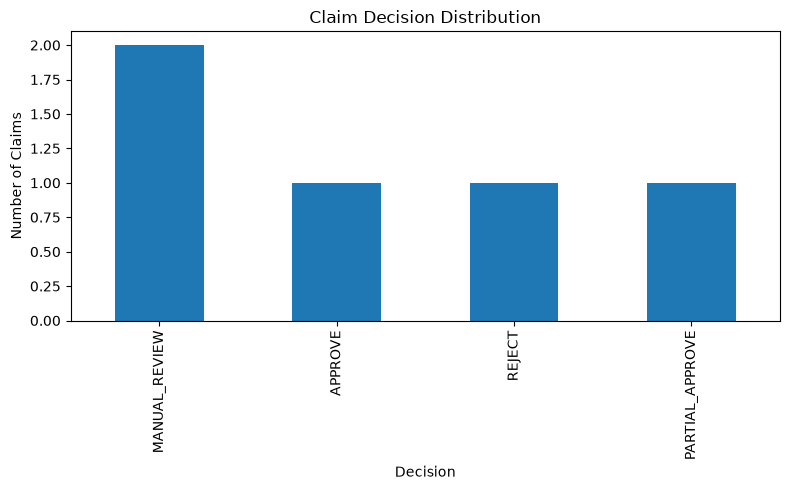

In [34]:
plt.figure(figsize=(8,5))

dashboard_df["decision"].value_counts().plot(
    kind="bar"
)

plt.title(
    "Claim Decision Distribution"
)

plt.xlabel(
    "Decision"
)

plt.ylabel(
    "Number of Claims"
)

plt.tight_layout()

plt.show()

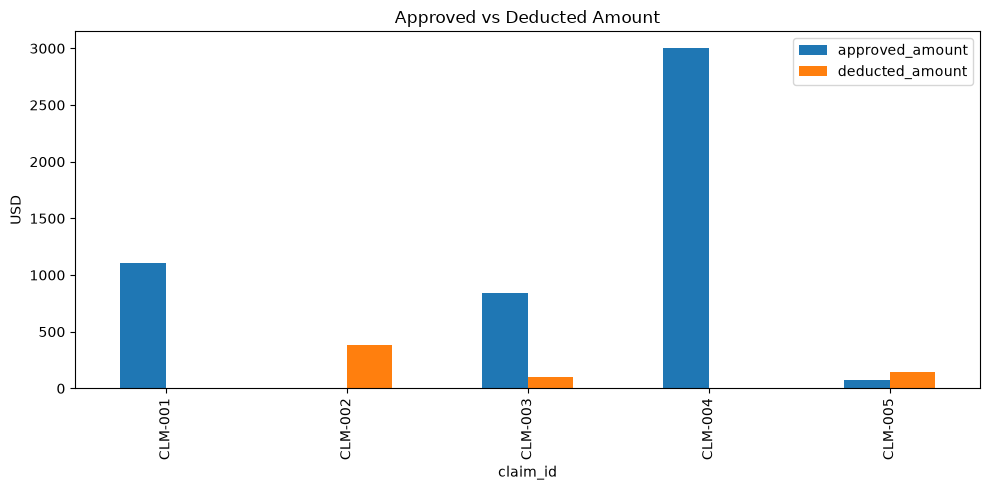

In [35]:
plot_df = dashboard_df[
    [
        "claim_id",
        "approved_amount",
        "deducted_amount",
    ]
]

plot_df = plot_df.set_index(
    "claim_id"
)

plot_df.plot(
    kind="bar",
    figsize=(10,5)
)

plt.title(
    "Approved vs Deducted Amount"
)

plt.ylabel(
    "USD"
)

plt.tight_layout()

plt.show()

In [36]:
claim_dropdown = widgets.Dropdown(
    options=dashboard_df["claim_id"]
)

output = widgets.Output()


def show_claim(change):

    output.clear_output()

    claim_id = (
        claim_dropdown.value
    )

    result = next(
        r
        for r in final_results
        if r["claim_id"] == claim_id
    )

    with output:
        display(
            pd.DataFrame([result])
        )


claim_dropdown.observe(
    show_claim,
    names="value",
)

display(claim_dropdown)
display(output)

show_claim(None)

Dropdown(options=('CLM-001', 'CLM-002', 'CLM-003', 'CLM-004', 'CLM-005'), value='CLM-001')

Output()

# Sample Outputs

The following examples demonstrate the recommendations generated by the Travel Reimbursement Approval Agent.

In [37]:
for result in final_results[:3]:

    print(
        "=" * 60
    )

    print(
        json.dumps(
            result,
            indent=2,
        )
    )

{
  "claim_id": "CLM-001",
  "decision": "APPROVE",
  "approved_amount": 1110.0,
  "deducted_amount": 0.0,
  "missing_docs": [],
  "policy_refs": [
    "POL-AIR-01",
    "POL-APR-02",
    "POL-CAT-01",
    "POL-PD-01",
    "POL-PD-02",
    "POL-RCT-01",
    "POL-TIME-01"
  ],
  "confidence": 0.99,
  "explanation": "All expenses are compliant with the reimbursement policy.",
  "tools_used": [
    "validate_claim_input",
    "lookup_policy",
    "check_category_eligibility",
    "check_receipt_completeness",
    "check_airfare_compliance",
    "check_submission_timeliness",
    "check_per_diem_limits",
    "check_approval_threshold"
  ]
}
{
  "claim_id": "CLM-002",
  "decision": "REJECT",
  "approved_amount": 0.0,
  "deducted_amount": 380.0,
  "missing_docs": [],
  "policy_refs": [
    "POL-APR-01",
    "POL-CAT-02",
    "POL-RCT-01",
    "POL-TIME-01"
  ],
  "confidence": 0.99,
  "explanation": "All claimed expenses fall under explicitly ineligible categories.",
  "tools_used": [
    "v

# Design Notes & Reasoning

## Why Deterministic Tools?

Reimbursement policies involve financial calculations and approval authority rules.

To maximize reliability and avoid hallucinations:

- Policy enforcement is deterministic.
- Financial calculations are deterministic.
- Approval thresholds are deterministic.
- Receipt validation is deterministic.

## Why Use GenAI?

The Groq-hosted LLM is used only for:

- Audit summaries
- Explanation generation
- Policy narrative generation

The LLM does not calculate reimbursement amounts.

## Manual Review Philosophy

The policy explicitly states:

> Prefer Manual Review over forcing a decision.

Therefore, claims are routed to Manual Review when:

- Required receipts are missing
- Airfare class requires exception handling
- Approval authority thresholds are exceeded
- Ambiguous information exists

## Trade-Offs

### Advantages

- Transparent
- Auditable
- Reliable
- Easy to test

### Limitations

- Small in-memory policy database
- Limited claim volume
- No external approval system integration

## Future Improvements

- Retrieval-Augmented Policy Search
- Real-time approval workflows
- Human approval dashboard
- Multi-step agent planning
- Automated evaluation metrics

# Assumptions and Limitations

## Assumptions

- Trip end date represents the latest expense date.
- Receipt metadata supplied with each claim is accurate.
- All reimbursement values are expressed in USD.
- The supplied policy is authoritative.

## Known Limitations

- No real document processing.
- No OCR extraction.
- No ERP integration.
- No approval workflow system.
- No external databases.

This implementation is intentionally lightweight and aligned with the assignment time constraints.

In [38]:
import json

print(
    json.dumps(
        final_results,
        indent=2,
    )
)

[
  {
    "claim_id": "CLM-001",
    "decision": "APPROVE",
    "approved_amount": 1110.0,
    "deducted_amount": 0.0,
    "missing_docs": [],
    "policy_refs": [
      "POL-AIR-01",
      "POL-APR-02",
      "POL-CAT-01",
      "POL-PD-01",
      "POL-PD-02",
      "POL-RCT-01",
      "POL-TIME-01"
    ],
    "confidence": 0.99,
    "explanation": "All expenses are compliant with the reimbursement policy.",
    "tools_used": [
      "validate_claim_input",
      "lookup_policy",
      "check_category_eligibility",
      "check_receipt_completeness",
      "check_airfare_compliance",
      "check_submission_timeliness",
      "check_per_diem_limits",
      "check_approval_threshold"
    ]
  },
  {
    "claim_id": "CLM-002",
    "decision": "REJECT",
    "approved_amount": 0.0,
    "deducted_amount": 380.0,
    "missing_docs": [],
    "policy_refs": [
      "POL-APR-01",
      "POL-CAT-02",
      "POL-RCT-01",
      "POL-TIME-01"
    ],
    "confidence": 0.99,
    "explanation": "All c